# II. Thay đổi tham số và quan sát kết quả
**Mục tiêu:** Khảo sát sự ảnh hưởng của từng tham số cấu hình đến thuật toán Canny.

1. **low_threshold:** Quản lý cạnh yếu (kết nối với cạnh phân cực). Ngưỡng càng thấp càng nhiều chi tiết vụn.
2. **high_threshold:** Điểm xuất phát của cạnh mạnh (seed). Ngưỡng cao giúp lọc nhiễu tốt.
3. **sigma (skimage):** Điều khiển filter mờ Gaussian.
4. **Gaussian Kernel:** Tiền xử lý (Blur) để làm mịn ảnh trước khi gọi `cv2.Canny`. Kernel 5x5 thường cho kết quả tốt nhất.
5. **So sánh tham số Default vs Tùy chỉnh.**

---
🔻 **CHẠY CELL CODE DƯỚI ĐÂY ĐỂ THỰC THI TOÀN BỘ PHẦN II** 🔻

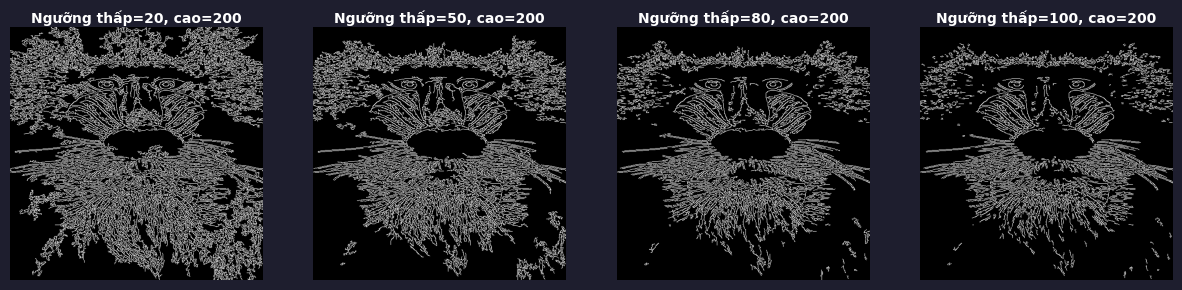

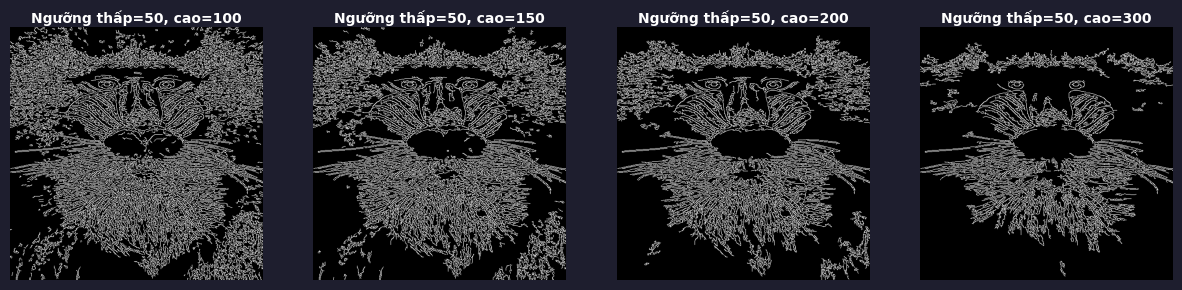

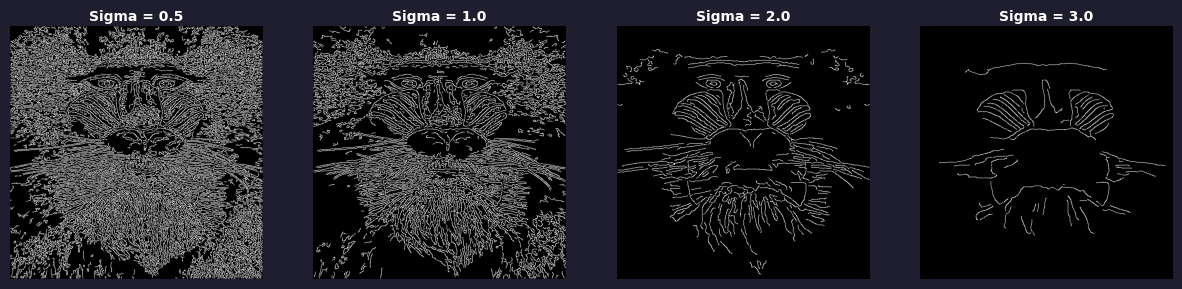

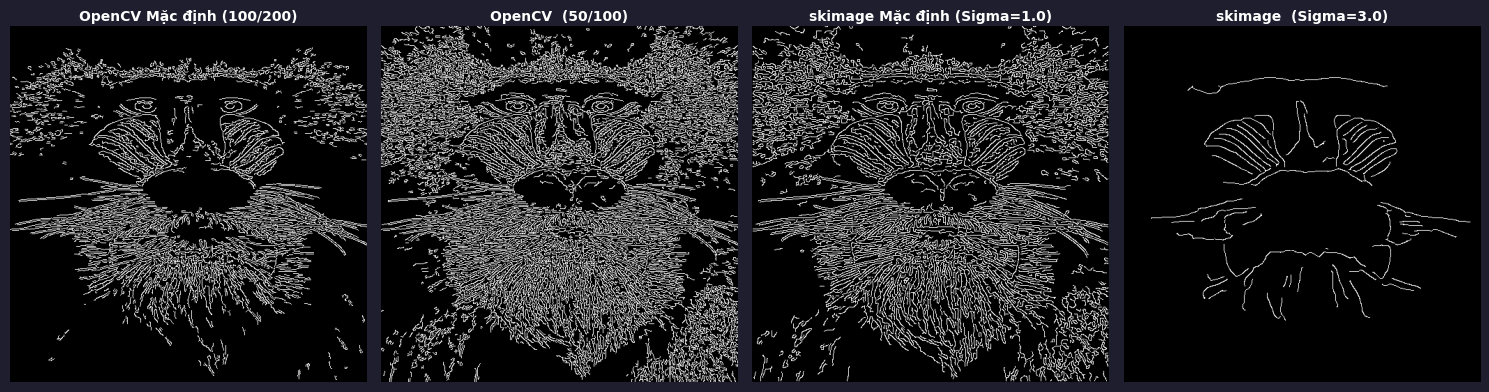

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.feature import canny as skimage_canny

# ==============================================================================
# 0. CÀI ĐẶT & ĐỌC ẢNH
# ==============================================================================
BASE_DIR = Path.cwd().parent
INPUT_PATH = BASE_DIR / "input" / "lab_image.jpg"

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy ảnh tại {INPUT_PATH}")

img_bgr = cv2.resize(cv2.imread(str(INPUT_PATH)), (512, 512), interpolation=cv2.INTER_AREA)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_f = img_gray.astype(np.float64) / 255.0

def show(ax, img, title):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, pad=4, fontsize=10, color="white")
    ax.axis("off")

fig_bg = "#1e1e2e"

# ==============================================================================
# YÊU CẦU 1: THAY ĐỔI THAM SỐ VÀ QUAN SÁT (Ngưỡng thấp, Ngưỡng cao, Sigma)
# ==============================================================================

# 1.1 Thay đổi Ngưỡng Thấp (Giữ nguyên ngưỡng cao = 200)
fig1, axes1 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)
for ax, lo in zip(axes1, [20, 50, 80, 100]):
    edge = cv2.Canny(img_gray, lo, 200)
    show(ax, edge, f"Ngưỡng thấp={lo}, cao=200")
plt.show()

# 1.2 Thay đổi Ngưỡng Cao (Giữ nguyên ngưỡng thấp = 50)
fig2, axes2 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)
for ax, hi in zip(axes2, [100, 150, 200, 300]):
    edge = cv2.Canny(img_gray, 50, hi)
    show(ax, edge, f"Ngưỡng thấp=50, cao={hi}")
plt.show()

# 1.3 Thay đổi Sigma (Dùng thư viện skimage)
fig3, axes3 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)
for ax, sigma in zip(axes3, [0.5, 1.0, 2.0, 3.0]):
    edge = skimage_canny(gray_f, sigma=sigma)
    show(ax, edge, f"Sigma = {sigma}")
plt.show()

# ==============================================================================
# YÊU CẦU 2: SO SÁNH KẾT QUẢ VỚI GIÁ TRỊ MẶC ĐỊNH
# ==============================================================================
fig4, axes4 = plt.subplots(1, 4, figsize=(15, 4), facecolor=fig_bg)

# Chạy thuật toán
edge_cv2_def = cv2.Canny(img_gray, 100, 200)      
edge_cv2_mod = cv2.Canny(img_gray, 50, 100)       
edge_ski_def = skimage_canny(gray_f)              
edge_ski_mod = skimage_canny(gray_f, sigma=3.0)    

# Hiển thị so sánh
show(axes4[0], edge_cv2_def, "OpenCV Mặc định (100/200)")
show(axes4[1], edge_cv2_mod, "OpenCV  (50/100)")
show(axes4[2], edge_ski_def, "skimage Mặc định (Sigma=1.0)")
show(axes4[3], edge_ski_mod, "skimage  (Sigma=3.0)")

plt.tight_layout()
plt.show()